## Paquid dataset application using the `jmstate` package

In [1]:
%pip install -q jmstate==0.15.1 pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import torch

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)


In [3]:
torch.manual_seed(42)

paquid = pd.read_csv("../data/paquid.csv")

# Convert all numeric columns to float32
numeric_cols = paquid.select_dtypes(include="number").columns
paquid[numeric_cols] = paquid[numeric_cols].astype("float32")

In [4]:
groups = paquid.groupby("ID")
ids = range(1, 501)
pad = torch.nn.utils.rnn.pad_sequence

trajectories, c, t, y, x = [], [], [], [], []

for i in ids:
    g = groups.get_group(i)

    s = g.groupby("HIER")["age"].min().reindex(range(4)).dropna()
    s = s[s >= s.cummax()]
    trajectories.append([((float(a) - 65) / 10, int(k)) for k, a in s.items()])

    c.append((g["age"].max() - 65) / 10)
    t.append((torch.tensor(g["age"].values) - 65) / 10)
    y.append(torch.tensor(g["MMSE"].values / 30))
    x.append(torch.tensor(g[["CEP", "male"]].iloc[0].values))

c = torch.tensor(c)[:, None]
t = pad(t, batch_first=True, padding_value=torch.nan)
y = pad(y, batch_first=True, padding_value=torch.nan)[..., None]
x = torch.stack(x)


In [5]:
from jmstate.utils import build_buckets

buckets = build_buckets(trajectories)
print({k: v.idxs.numel() for k, v in buckets.items()})

{(0, 1): 85, (0, 2): 44, (0, 3): 11, (1, 2): 135, (1, 3): 15, (2, 3): 86}


In [6]:
from jmstate.types import ModelDesign


def sigmoid(t: torch.Tensor, indiv_params: torch.Tensor):
    scale, offset, slope = indiv_params.chunk(3, dim=-1)
    return (scale * torch.sigmoid((offset - t) / slope)).unsqueeze(-1)


def f(fixed: torch.Tensor, x: torch.Tensor, b: torch.Tensor):
    x_aug = torch.cat([torch.ones(x.shape[0], 1), x], dim=-1)
    fixed = fixed.reshape(3, 3)
    indiv_params = x_aug @ fixed.T + b
    indiv_params[..., -1] = indiv_params[..., -1].exp()
    return indiv_params


# Define model design and link functions
link_fns = dict.fromkeys(buckets, sigmoid)
design = ModelDesign(f, sigmoid, link_fns)

In [7]:
from jmstate.types import ModelData
from sklearn.model_selection import train_test_split

(
    x_train,
    x_test,
    t_train,
    t_test,
    y_train,
    y_test,
    trajectories_train,
    trajectories_test,
    c_train,
    c_test,
) = train_test_split(x, t, y, trajectories, c, test_size=0.2, random_state=42)

data_train = ModelData(x_train, t_train, y_train, trajectories_train, c_train)
data_test = ModelData(x_test, t_test, y_test, trajectories_test, c_test)

In [8]:
from jmstate import MultiStateJointModel
from jmstate.functions.base_hazards import Weibull
from jmstate.types import ModelParameters, PrecisionParameters
from torch import nn

# Populate parameters sharing the same memory address
shared_x_coef = nn.Parameter(torch.zeros(2))

params = ModelParameters(
    torch.zeros(9).index_put((torch.tensor(0),), torch.tensor(1.0)),
    PrecisionParameters.from_covariance(torch.eye(3), "full"),
    PrecisionParameters.from_covariance(torch.eye(1), "spherical"),
    {key: Weibull(1.0, 1.0) for key in buckets},
    {key: torch.zeros(1) for key in buckets},
    dict.fromkeys(buckets, shared_x_coef),
)

torch.manual_seed(42)
optimizer = torch.optim.Adam(params.parameters(), lr=0.1)
model = MultiStateJointModel(
    design, params, optimizer, max_iter_fit=5000, window_size=500
).fit(data_train)

Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:08<00:00, 12.09it/s]


╭───────────────────────────────────────────── Model Summary ─────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name                  ┃  Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ fixed_effects[0]                │  1.182  │     0.040      │ 29.842  │  0.000  │        ***         │ │
│ │ fixed_effects[1]                │  0.250  │     0.046      │  5.475  │  0.000  │        ***         │ │
│ │ fixed_effects[2]                │  0.125  │     0.045      │  2.780  │  0.005  │         **         │ │
│ │ fixed_effects[3]                │  3.428  │     0.123      │ 27.811  │  0.000  │        ***         │ │
│ │ fixed_effects[4]                │  0.211  │     0.131      │  1.604  │  0.109  │                    │ │
│ │ fixed_effects[5]                │  0.391  │     0.152      │  2.578  │  0.010  │         **         │ │
│ │ fixed_effects[6]                │  0.534  │     0.222      │  2.406  │  0.016  │         *          │ │
│ │ fixed_effects[7]                │  0.941  │     0.258      │  3.650  │  0.000  │        ***         │ │
│ │ fixed_effects[8]                │  0.808  │     0.240      │  3.360  │  0.001  │        ***         │ │
│ │ random_prec.flat[0]             │  2.536  │     0.094      │ 27.079  │  0.000  │        ***         │ │
│ │ random_prec.flat[1]             │  0.003  │     0.354      │  0.007  │  0.994  │                    │ │
│ │ random_prec.flat[2]             │  0.584  │     0.098      │  5.926  │  0.000  │        ***         │ │
│ │ random_prec.flat[3]             │ -1.910  │     0.169      │ 11.321  │  0.000  │        ***         │ │
│ │ random_prec.flat[4]             │ -0.765  │     0.110      │  6.984  │  0.000  │        ***         │ │
│ │ random_prec.flat[5]             │ -0.723  │     0.080      │  9.009  │  0.000  │        ***         │ │
│ │ noise_prec.flat[0]              │  2.985  │     0.009      │ 340.555 │  0.000  │        ***         │ │
│ │ base_hazards.(0, 1).log_lmda[0] │ -1.292  │     1.251      │  1.033  │  0.302  │                    │ │
│ │ base_hazards.(0, 1).log_k[0]    │  0.240  │     0.146      │  1.642  │  0.101  │                    │ │
│ │ base_hazards.(0, 2).log_lmda[0] │  1.687  │     0.616      │  2.740  │  0.006  │         **         │ │
│ │ base_hazards.(0, 2).log_k[0]    │  0.703  │     0.152      │  4.627  │  0.000  │        ***         │ │
│ │ base_hazards.(0, 3).log_lmda[0] │  3.633  │     2.234      │  1.626  │  0.104  │                    │ │
│ │ base_hazards.(0, 3).log_k[0]    │  0.657  │     0.523      │  1.255  │  0.209  │                    │ │
│ │ base_hazards.(1, 2).log_lmda[0] │  1.217  │     0.634      │  1.919  │  0.055  │         .          │ │
│ │ base_hazards.(1, 2).log_k[0]    │  0.456  │     0.110      │  4.153  │  0.000  │        ***         │ │
│ │ base_hazards.(1, 3).log_lmda[0] │  2.657  │     0.955      │  2.784  │  0.005  │         **         │ │
│ │ base_hazards.(1, 3).log_k[0]    │  0.512  │     0.303      │  1.691  │  0.091  │         .          │ │
│ │ base_hazards.(2, 3).log_lmda[0] │  2.148  │     0.371      │  5.786  │  0.000  │        ***         │ │
│ │ base_hazards.(2, 3).log_k[0]    │  0.517  │     0.113      │  4.560  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[0]            │  1.314  │     1.813      │  0.725  │  0.469  │                    │ │
│ │ link_coefs.(0, 2)[0]            │ -5.202  │     1.420      │  3.663  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 3)[0]            │ -12.006 │     2.091      │  5.741  │  0.000  │        ***         │ │
│ │ link_coefs.(1, 2)[0]            │ -2.261  │     1.126      │  2.008  │  0.045  │         *          │ │
│ │ link_coefs.(1, 3)[0]            │ -7.929  │     0.952      │  8.327  │  0.000  │        ***         │ │
│ │ 

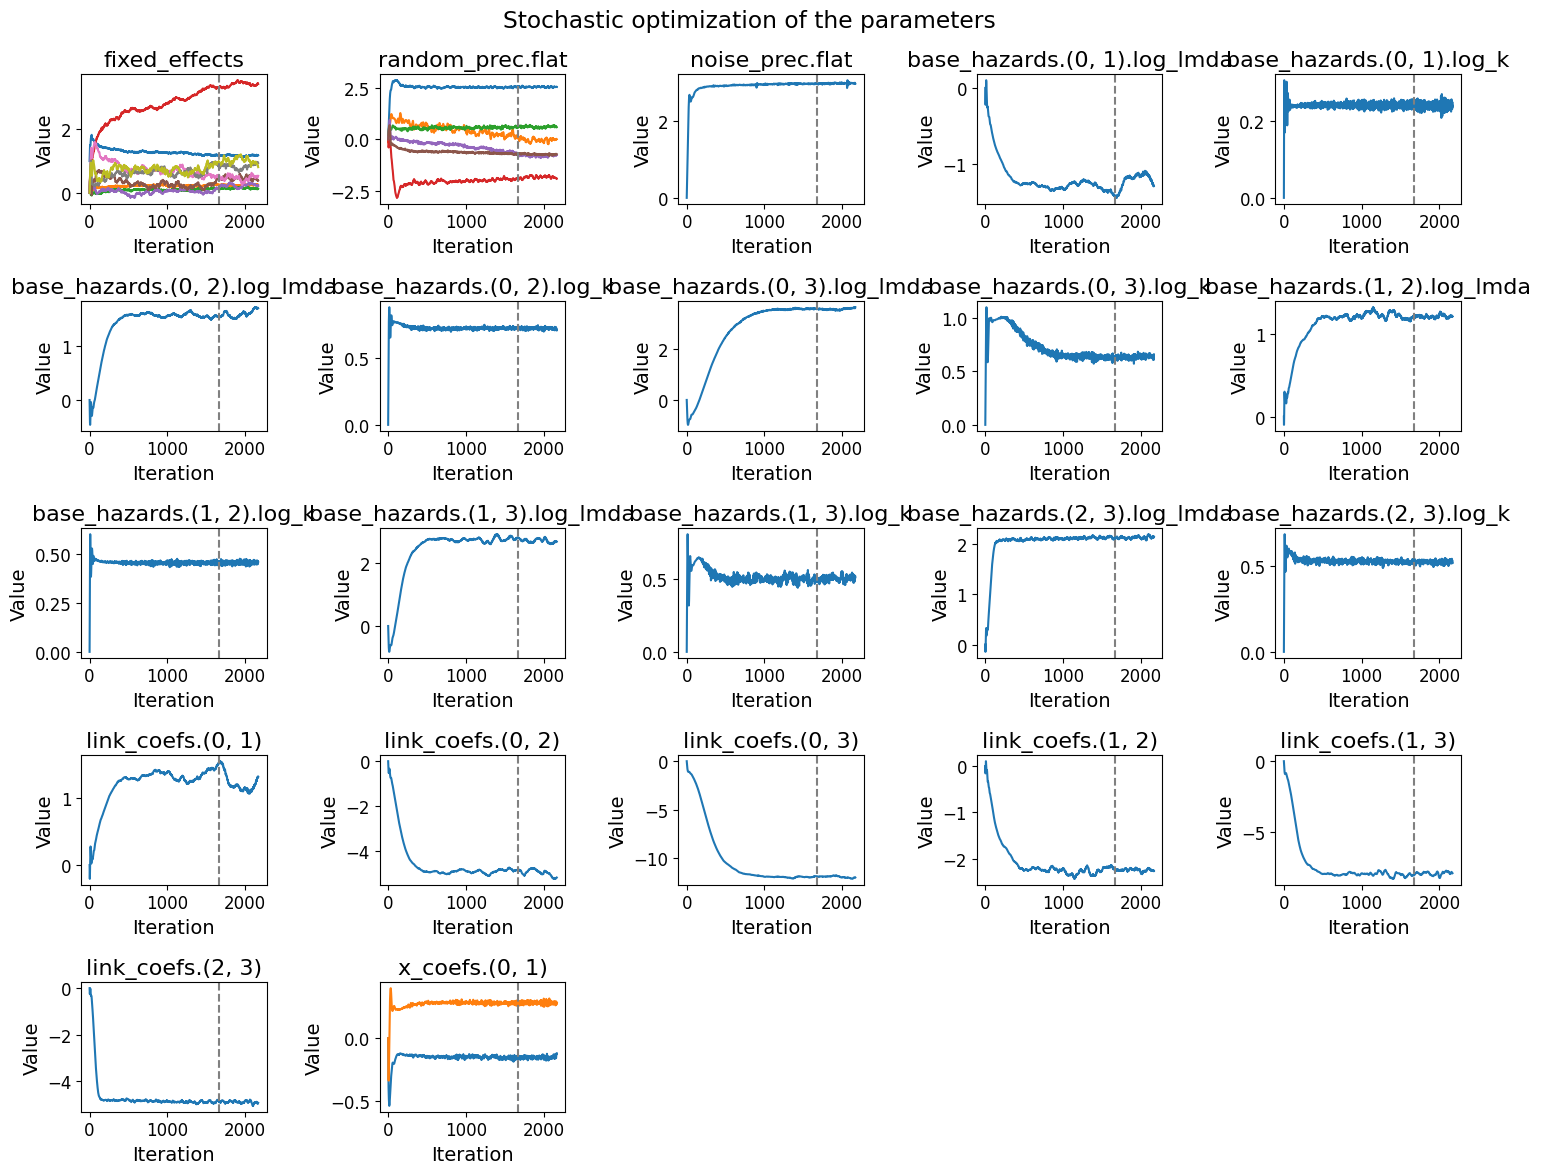

In [9]:
from jmstate.utils import plot_params_history, summary

summary(model)

fig, axes = plot_params_history(model, figsize=(15, 12))

conv = len(model.params_history_) - model.window_size
for ax in axes:
    ax.axvline(x=conv, c="gray", linestyle="--")
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig("../figures/paquid-optimization.pdf")
plt.show()

In [10]:
from dataclasses import replace


def predict_cond(cond_time: float):
    trajectories_cond = [
        [traj[0]] + [(t, s) for (t, s) in traj[1:] if t <= cond_time]
        for traj in data_test.trajectories
    ]
    c = torch.tensor([traj[-1][0] for traj in trajectories_cond])[:, None]

    y_trunc = data_test.y.clone()
    y_trunc[data_test.t > cond_time] = torch.nan

    data_test_cond = replace(
        data_test,
        y=y_trunc,
        trajectories=trajectories_cond,
        c=torch.maximum(c, cond_time),
    )
    return model.predict_trajectories(data_test_cond, c=data_test.c, n_samples=100)


def hier_probs(pred_trajectories: list[list[list[tuple[float, Any]]]], u: float):
    counts = torch.zeros(len(pred_trajectories[0]), 4)

    for trajectories in pred_trajectories:
        for i, trajectory in enumerate(trajectories):
            last_valid_state = trajectory[0][1]
            for t, s in reversed(trajectory):
                if t <= u:
                    last_valid_state = s
                    break

            counts[i][last_valid_state] += 1

    return counts / len(pred_trajectories)


def normalized_brier(
    pred_probs: torch.Tensor, real_states: torch.Tensor, n_boot=1000, alpha=0.05
):
    bs_model = ((pred_probs - real_states) ** 2).mean()
    baseline = real_states.mean(dim=0)
    bs_baseline = ((baseline - real_states) ** 2).mean()
    est = 1 - (bs_model / bs_baseline).item()

    boot_stats = []
    n = pred_probs.shape[0]
    for _ in range(n_boot):
        idx = torch.randint(0, n, (n,))
        bs_m = ((pred_probs[idx] - real_states[idx]) ** 2).mean()
        bs_b = ((real_states[idx].mean(dim=0) - real_states[idx]) ** 2).mean()
        boot_stats.append((1 - (bs_m / (1e-16 + bs_b))).item())
    boot_stats = torch.tensor(boot_stats)
    lower = boot_stats.quantile(alpha / 2).item()
    upper = boot_stats.quantile(1 - alpha / 2).item()

    return est, lower, upper


def accuracy(
    pred_probs: torch.Tensor, real_states: torch.Tensor, n_boot=1000, alpha=0.05
):
    pred = pred_probs.argmax(dim=1)
    real = real_states.argmax(dim=1)
    est = torch.mean((pred == real).float()).item()
    boot_stats = []
    n = pred_probs.shape[0]
    for _ in range(n_boot):
        idx = torch.randint(0, n, (n,))
        p = pred[idx]
        r = real[idx]
        boot_stats.append(torch.mean((p == r).float()).item())
    boot_stats = torch.tensor(boot_stats)
    lower = boot_stats.quantile(alpha / 2).item()
    upper = boot_stats.quantile(1 - alpha / 2).item()

    return est, lower, upper

In [11]:
# Define landmark times on which to condition
cond_times = torch.linspace(0, data_test.c.max(), 5)[1:-1]
us = torch.linspace(0, 4, 50)

B = torch.zeros(len(cond_times), len(us), 3)
A = torch.zeros(len(cond_times), len(us), 3)

torch.manual_seed(42)
for i, cond_time in enumerate(cond_times):
    pred_trajectories = predict_cond(cond_time)
    for j, u in enumerate(us):
        pred_probs = hier_probs(pred_trajectories, u)
        real_states = hier_probs([data_test.trajectories], u)
        B[i, j] = torch.tensor(normalized_brier(pred_probs, real_states))
        A[i, j] = torch.tensor(accuracy(pred_probs, real_states))


Predicting trajectories: 100%|██████████| 20/20 [00:05<00:00,  3.47it/s]


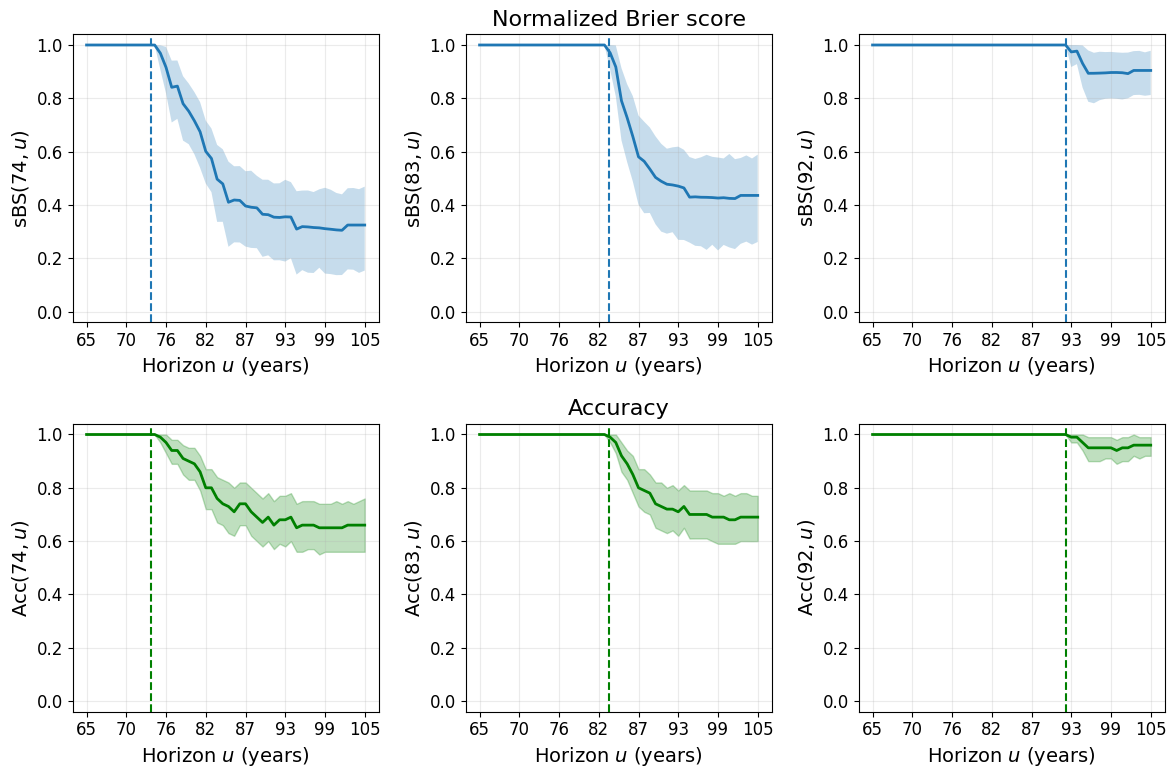

In [12]:
with plt.rc_context(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))

    age_ticks = [int(65 + 10 * u) for u in us[::7]]
    for i, cond_time in enumerate(cond_times):
        cond_age = int(65 + cond_time * 10)

        # Top
        ax = axes[0, i]
        ax.plot(us, B[i, :, 0], linewidth=2)
        ax.fill_between(us, B[i, :, 1], B[i, :, 2], alpha=0.25)
        ax.axvline(cond_time, linestyle="--")
        ax.set_ylabel(rf"$\mathrm{{sBS}}({cond_age}, u)$")
        ax.set_xlabel(r"Horizon $u$ (years)")
        ax.set_xticks(us[::7])
        ax.set_xticklabels(age_ticks)
        ax.grid(alpha=0.25)
        ax.set_ylim(-0.04, 1.04)

        # Bottom
        ax = axes[1, i]
        ax.plot(us, A[i, :, 0], linewidth=2, color="green")
        ax.fill_between(us, A[i, :, 1], A[i, :, 2], alpha=0.25, color="green")
        ax.axvline(cond_time, linestyle="--", color="green")
        ax.set_ylabel(rf"$\mathrm{{Acc}}({cond_age}, u)$")
        ax.set_xlabel(r"Horizon $u$ (years)")
        ax.set_xticks(us[::7])
        ax.set_xticklabels(age_ticks)
        ax.grid(alpha=0.25)
        ax.set_ylim(-0.04, 1.04)

    axes[0, 1].set_title("Normalized Brier score")
    axes[1, 1].set_title("Accuracy")

    plt.tight_layout()
    plt.savefig("../figures/paquid-accuracy.pdf")
    plt.show()